## Professor Rating NLP

In [89]:
# install dependencies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## Data exploration

In [90]:
# path of csv file
file_path = "RateMyProfessor-9c.csv"

# Read the CSV file
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

# Optional: show basic info about the dataset
print(df.info())

   id  professor_name                                 school_name  \
0   1  Leslie  Looney  University Of Illinois at Urbana-Champaign   
1   2  Leslie  Looney  University Of Illinois at Urbana-Champaign   
2   3  Leslie  Looney  University Of Illinois at Urbana-Champaign   
3   4  Leslie  Looney  University Of Illinois at Urbana-Champaign   
4   5  Leslie  Looney  University Of Illinois at Urbana-Champaign   

        department_name state_name  \
0  Astronomy department         IL   
1  Astronomy department         IL   
2  Astronomy department         IL   
3  Astronomy department         IL   
4  Astronomy department         IL   

                                       tag_professor student_star  \
0  Hilarious (2)  GROUP PROJECTS (2)  Gives good ...          5.0   
1  Hilarious (2)  GROUP PROJECTS (2)  Gives good ...          5.0   
2  Hilarious (2)  GROUP PROJECTS (2)  Gives good ...          4.0   
3  Hilarious (2)  GROUP PROJECTS (2)  Gives good ...          5.0   
4  Hilariou

In [91]:
# Summary statistics for numeric columns
print(df.describe())

                 id  gives_good_feedback        caring     respected  \
count  19994.000000         19994.000000  19994.000000  19994.000000   
mean    9997.500000             0.303091      0.264379      0.279634   
std     5771.914977             0.459606      0.441013      0.448831   
min        1.000000             0.000000      0.000000      0.000000   
25%     4999.250000             0.000000      0.000000      0.000000   
50%     9997.500000             0.000000      0.000000      0.000000   
75%    14995.750000             1.000000      1.000000      1.000000   
max    19994.000000             1.000000      1.000000      1.000000   

       participation_matters  clear_grading_criteria    skip_class  \
count           19994.000000            19994.000000  19994.000000   
mean                0.248725                0.222867      0.279334   
std                 0.432285                0.416180      0.448683   
min                 0.000000                0.000000      0.000000   
2

In [92]:
print(df.columns)
print(df["student_star"].describe())
print(df["student_star"].unique())
print(df["student_star"].value_counts().sort_index())





Index(['id', 'professor_name', 'school_name', 'department_name', 'state_name',
       'tag_professor', 'student_star', 'comments', 'gives_good_feedback',
       'caring', 'respected', 'participation_matters',
       'clear_grading_criteria', 'skip_class', 'amazing_lectures',
       'inspirational', 'tough_grader', 'hilarious', 'get_ready_to_read',
       'lots_of_homework', 'accessible_outside_class', 'lecture_heavy',
       'extra_credit', 'graded_by_few_things', 'group_projects', 'test_heavy',
       'so_many_papers', 'beware_of_pop_quizzes', 'IsCourseOnline'],
      dtype='object')
count     19994
unique       11
top         5.0
freq       7043
Name: student_star, dtype: object
['5.0' '4.0' '4.5' '2.0' '3.5' '1.5' '2.5' '3.0' '1.0' 'STATS'
 'STATISTICS']
student_star
1.0           2594
1.5            911
2.0           1259
2.5            915
3.0           1388
3.5           1116
4.0           2408
4.5           2357
5.0           7043
STATISTICS       1
STATS            2
Name: coun

In [93]:
# List of label columns to summarize
label_cols = [
    'gives_good_feedback', 'caring', 'respected', 'participation_matters',
    'clear_grading_criteria', 'skip_class', 'amazing_lectures',
    'inspirational', 'tough_grader', 'hilarious', 'get_ready_to_read',
    'lots_of_homework', 'accessible_outside_class', 'lecture_heavy',
    'extra_credit', 'graded_by_few_things', 'group_projects', 'test_heavy',
    'so_many_papers', 'beware_of_pop_quizzes', 'IsCourseOnline'
]

# Count how many times each label is marked (assuming 1 = True, 0 = False)
feedback_counts = df[label_cols].sum().sort_values(ascending=False)

# Display nicely
print(feedback_counts)


tough_grader                6742
gives_good_feedback         6060
respected                   5591
skip_class                  5585
caring                      5286
get_ready_to_read           5274
participation_matters       4973
clear_grading_criteria      4456
lecture_heavy               4355
lots_of_homework            4027
amazing_lectures            4004
inspirational               3956
hilarious                   3901
accessible_outside_class    2679
extra_credit                2317
graded_by_few_things        2050
test_heavy                  1967
group_projects              1614
so_many_papers              1535
beware_of_pop_quizzes       1352
IsCourseOnline               402
dtype: int64


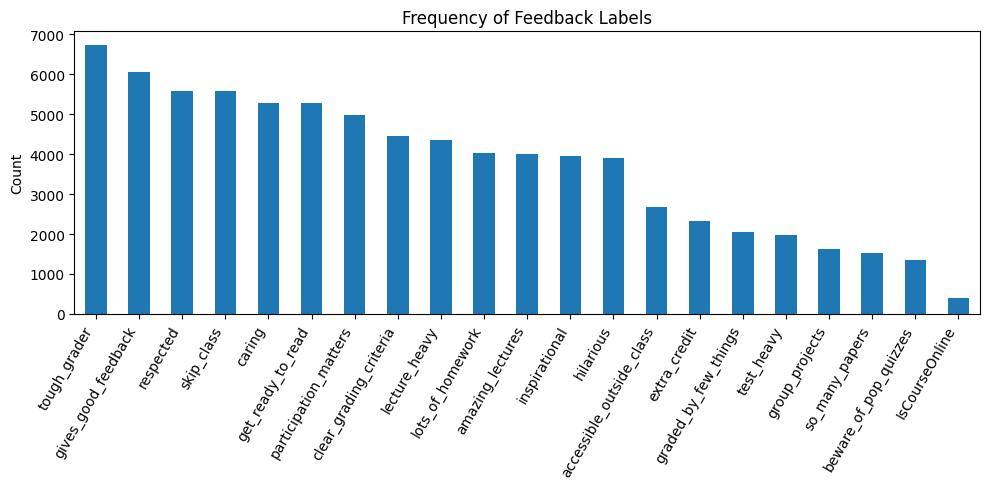

In [94]:
feedback_counts.plot(kind='bar', figsize=(10,5))
plt.title("Frequency of Feedback Labels")
plt.ylabel("Count")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


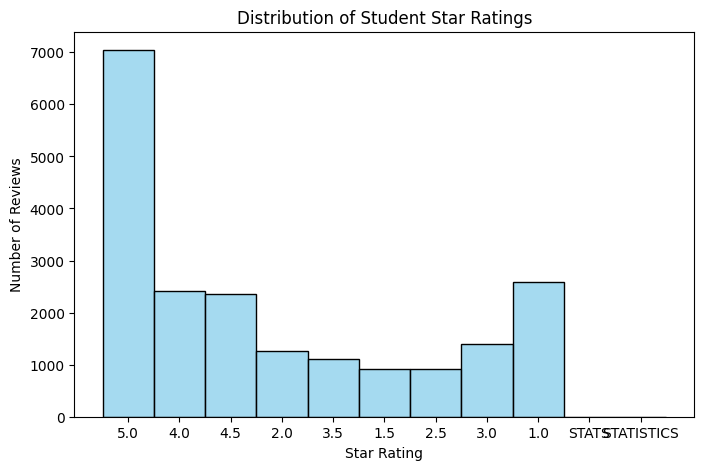

In [95]:
plt.figure(figsize=(8,5))
sns.histplot(df["student_star"], bins=9, kde=False, color="skyblue")
plt.title("Distribution of Student Star Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.show()


## Tokenization

In [96]:
import os
import nltk
from nltk.tokenize import word_tokenize

# (Optional) set a fixed local data folder to avoid permission/path issues on Windows
nltk.data.path.append(os.path.expanduser(r"C:\Users\Owner\nltk_data"))

# Newer NLTK may need BOTH packages:
for pkg in ("punkt", "punkt_tab"):
    nltk.download(pkg, quiet=True)

# Tokenize
df["tokens"] = df["comments"].astype(str).apply(lambda x: word_tokenize(x.lower()))
print(df["tokens"].head())


0    [this, class, is, hard, but, its, a, two-in-on...
1    [definitely, going, to, choose, prof., looney,...
2    [i, overall, enjoyed, this, class, because, th...
3    [yes, it, 's, possible, to, get, an, a, but, y...
4    [professor, looney, has, great, knowledge, in,...
Name: tokens, dtype: object


## Feature Engineering

In [97]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Identity functions so the vectorizers accept pre-tokenized input
identity = lambda x: x

# --- Bag of Words (counts) ---
bow = CountVectorizer(
    tokenizer=identity,          # accept tokens
    preprocessor=identity,
    token_pattern=None,          # disable internal regex
    lowercase=False,             # we already lowercased earlier
    max_features=5000,           # optional: cap vocab size
    min_df=2,                    # optional: drop rare tokens
    ngram_range=(1,1),           # unigrams; change to (1,2) for uni+bi-grams
    binary=False                 # set True for presence/absence features
)
X_bow = bow.fit_transform(df["tokens"])      # sparse matrix (n_docs x n_features)
bow_vocab = bow.get_feature_names_out()      # vocabulary order

# --- TF-IDF ---
tfidf = TfidfVectorizer(
    tokenizer=identity,
    preprocessor=identity,
    token_pattern=None,
    lowercase=False,
    max_features=5000,
    min_df=2,
    ngram_range=(1,1)            # try (1,2) for uni+bi-grams
)
X_tfidf = tfidf.fit_transform(df["tokens"])
tfidf_vocab = tfidf.get_feature_names_out()

# Example: show sizes
print("BOW shape:", X_bow.shape)
print("TFIDF shape:", X_tfidf.shape)

# If you need a (small) preview as a DataFrame:
import pandas as pd
preview = pd.DataFrame(X_bow[:5].toarray(), columns=bow_vocab)
print(preview.iloc[:, :15])  # first 15 features just to peek


BOW shape: (19994, 5000)
TFIDF shape: (19994, 5000)
   !  #  $  %  &  '  ''  'd  'll  'm  're  's  've  (  )
0  0  0  0  0  0  0   0   0    0   0    0   0    0  0  0
1  2  0  0  0  0  0   0   0    0   0    0   1    0  0  0
2  0  0  0  0  0  0   0   0    0   0    0   0    0  0  0
3  0  0  0  0  0  0   0   1    3   0    0   1    0  0  0
4  0  0  0  0  0  0   0   0    0   0    0   0    0  0  0


In [98]:
df["student_star"] = pd.to_numeric(df["student_star"], errors="coerce")
mask = df["comments"].notna() & df["student_star"].notna()

X = X_tfidf[mask.values]
y = df.loc[mask, "student_star"]

## Training

In [99]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (15992, 5000) Test shape: (3999, 5000)


In [100]:
from sklearn.linear_model import Ridge

reg = Ridge(alpha=1.0, random_state=42)
reg.fit(X_train, y_train)        # y_train is continuous star rating
y_pred = reg.predict(X_test)     # keep continuous predictions

## Evaluation

MAE=0.801  RMSE=1.012  R²=0.525


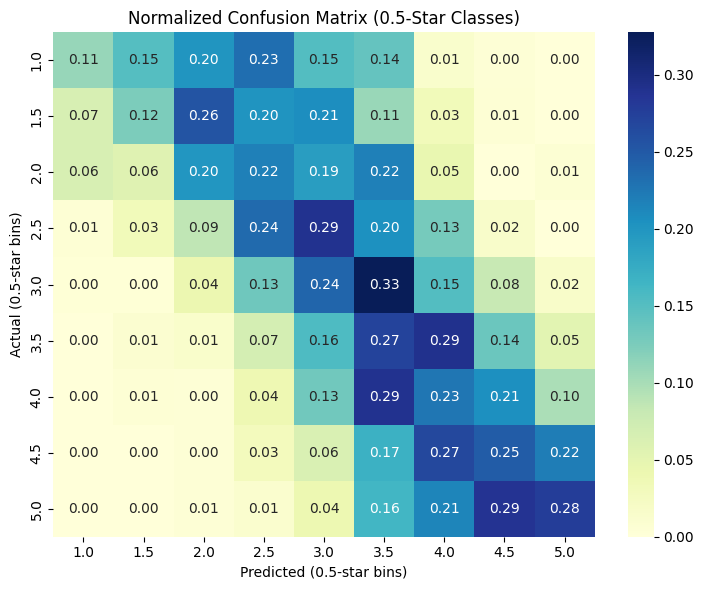

In [106]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Continuous metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
print(f"MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}")

# Bin true/pred into 0.5-star classes (NO rounding, just binning)
edges  = np.arange(0.75, 5.26, 0.5)           # (0.75,1.25], (1.25,1.75], ..., (4.75,5.25]
labels = np.arange(1.0, 5.1, 0.5)             # 1.0, 1.5, ..., 5.0

# 1) Clip to valid rating range
y_pred_c = np.clip(y_pred, 1.0, 5.0)
y_test_c = np.clip(y_test, 1.0, 5.0)

# 2) Bin into 0.5-star classes
edges  = np.arange(0.75, 5.26, 0.5)
labels = np.arange(1.0, 5.1, 0.5)

y_true_bin = pd.cut(y_test_c, bins=edges, labels=labels, include_lowest=True)
y_pred_bin = pd.cut(y_pred_c, bins=edges, labels=labels, include_lowest=True)

# 3) Ensure no NaNs remain (rare, but guard anyway)
mask = y_true_bin.notna() & y_pred_bin.notna()
y_true_b = y_true_bin[mask].astype(str)
y_pred_b = y_pred_bin[mask].astype(str)
classes  = [f"{x:.1f}" for x in labels]

# 4) Confusion matrix (row-normalized)
cm_norm = confusion_matrix(y_true_b, y_pred_b, labels=classes, normalize='true')


plt.figure(figsize=(7.5,6))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="YlGnBu",
    xticklabels=[f"{x:.1f}" for x in labels],
    yticklabels=[f"{x:.1f}" for x in labels]
)
plt.xlabel("Predicted (0.5-star bins)")
plt.ylabel("Actual (0.5-star bins)")
plt.title("Normalized Confusion Matrix (0.5-Star Classes)")
plt.tight_layout()
plt.show()

In [107]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true_b, y_pred_b)
print(f"Exact-match accuracy across 0.5-star bins: {acc:.3f}")


Exact-match accuracy across 0.5-star bins: 0.229


In [109]:
# --- accuracy within ±0.5 star margin ---
# Use the clipped continuous predictions
within_half = np.abs(y_pred_c - y_test_c) <= 0.5
acc_within_half = np.mean(within_half)

print(f"Accuracy within ±0.5-star margin: {acc_within_half:.3f}")


Accuracy within ±0.5-star margin: 0.418


## Future Steps

1. **Model Improvement**  
   - Tune TF-IDF parameters & hyperparameters  
   - Experiment with Ridge, SVR, and XGBoost  

2. **Feature Engineering**  
   - Add bigrams, sentiment, and review-length features  
   - Incorporate professor & department metadata  

3. **Evaluation**  
   - Apply cross-validation and ±0.5-star accuracy  
   - Analyze residuals and error patterns  

4. **Visualization**  
   - Plot feature importance and rating distributions  
   - Explore bias trends across departments  

5. **Deep Learning**  
   - Test out using deep learning methods

6. **Deployment**  
   - Build a Streamlit or Gradio web app for live predictions  

7. **Documentation**  
   - Save trained model & TF-IDF vectorizer  
   - Create a clear project report
